# Movies per year count

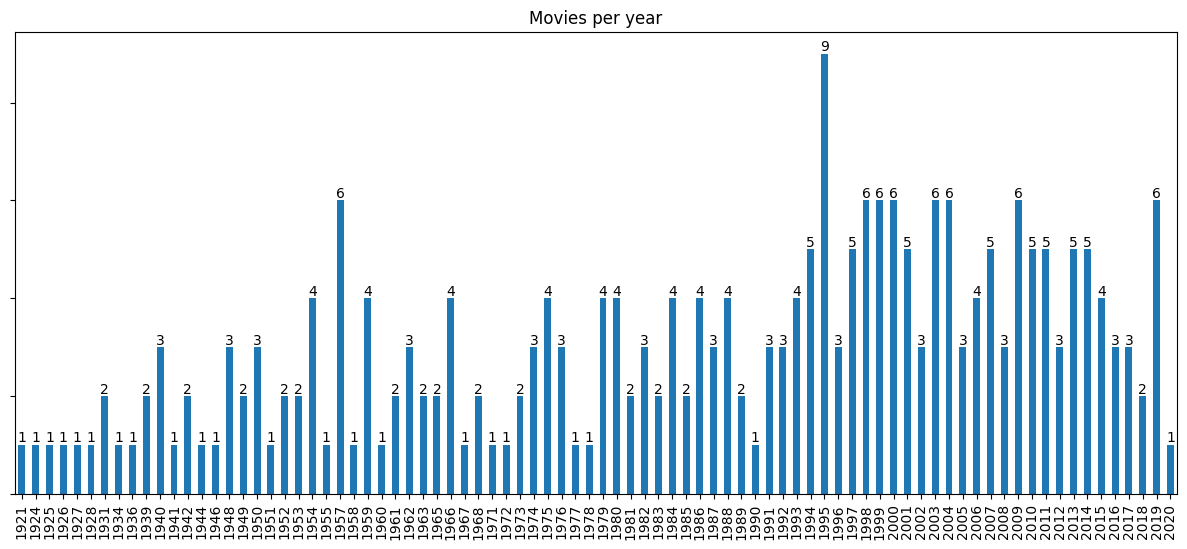

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud

def bar_labels(axes, rotation=0, location="edge", color="black"):
    for container in axes.containers:
        axes.bar_label(container, rotation=rotation, label_type=location, color=color)
    axes.set_xlabel("")
    axes.set_ylabel("")
    axes.set_yticklabels("")

df = pd.read_csv("/kaggle/input/imdb-top-250-movies/imdb_top_250.csv")

df.drop("Rank", axis=1, inplace=True)

fig, axes = plt.subplots(figsize=(15, 6))

df["Year"].value_counts().sort_index().plot(kind="bar", ax=axes)
bar_labels(axes)
axes.set_title("Movies per year")
plt.show()

# Runtime and Rating distribution

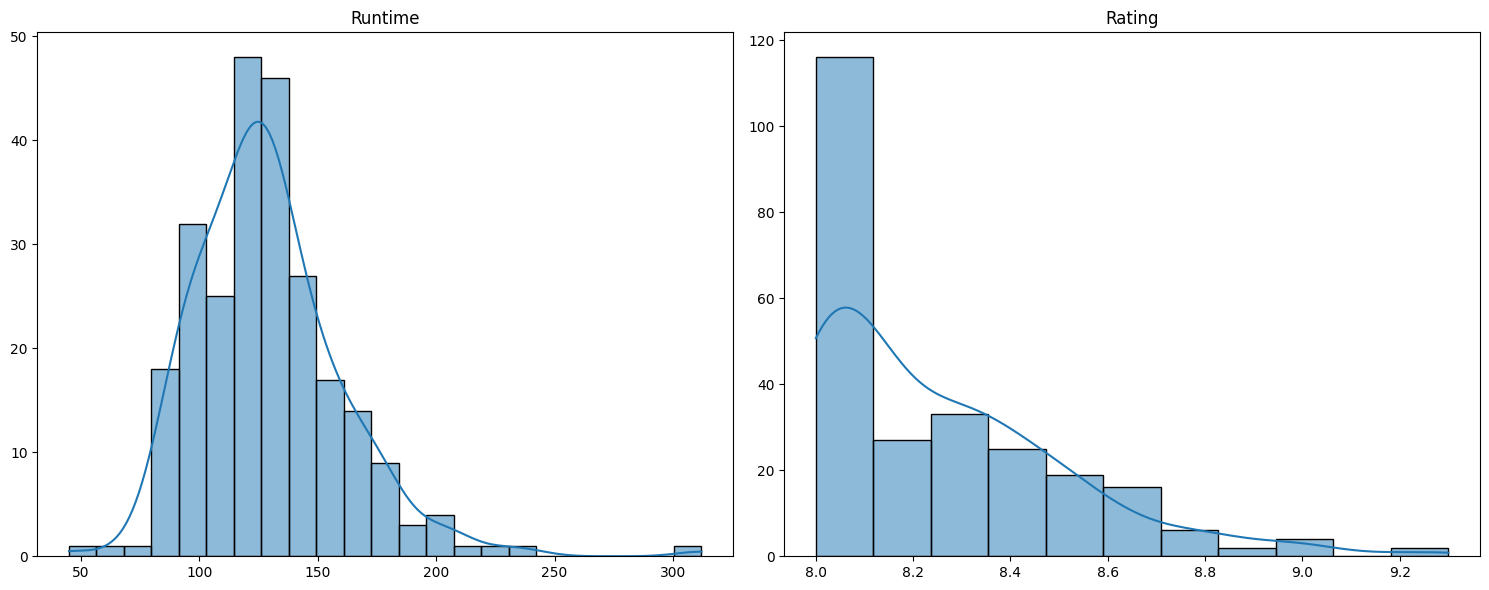

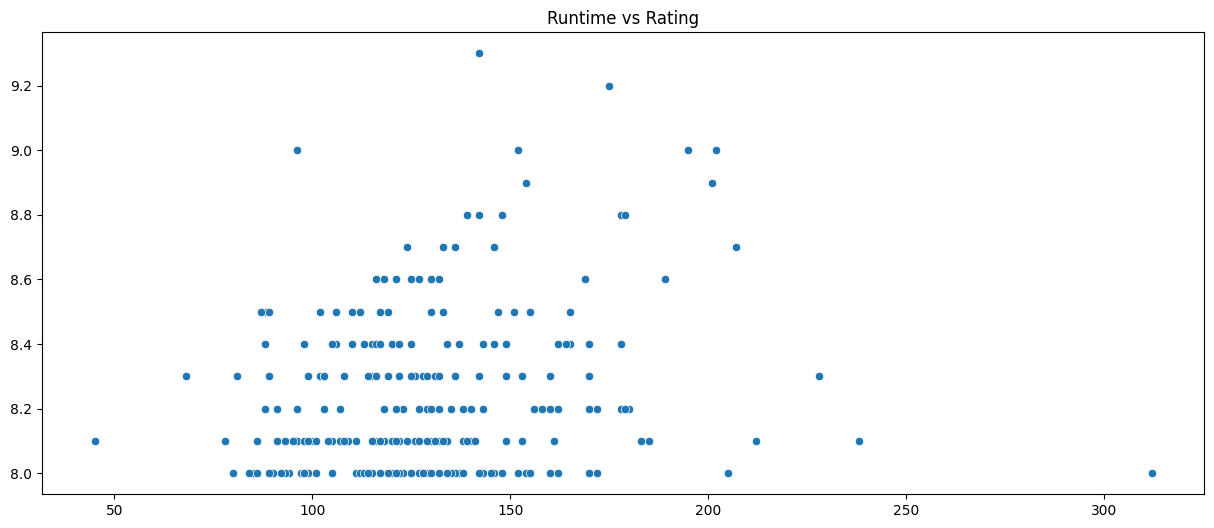

In [2]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

for i, j in enumerate(["Runtime", "Rating"]):
    sns.histplot(df, x=j, kde=True, ax=axes[i])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(j)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(15, 6))

sns.scatterplot(df, x="Runtime", y="Rating", ax=axes)
axes.set_xlabel("")
axes.set_ylabel("")
axes.set_title("Runtime vs Rating")
plt.show()

# Common title name words

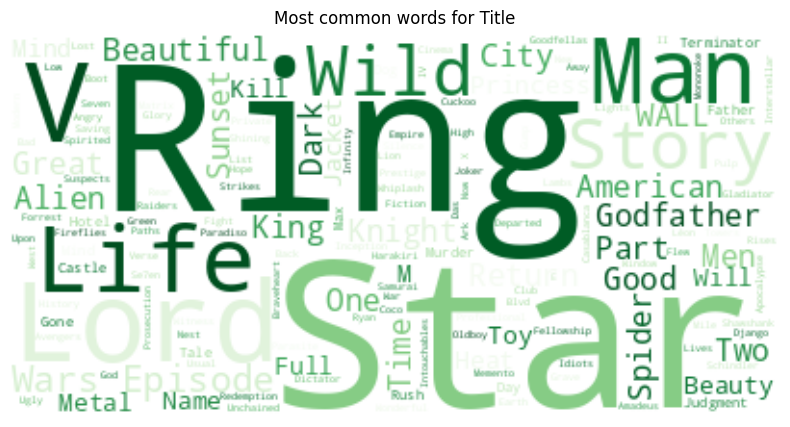

In [3]:
def wordclouds(col):

    words = " ".join(df[col])
    
    plt.figure(figsize=(10, 5))
    wordcloud_pos = WordCloud(background_color='white', colormap='Greens').generate(words)
    plt.imshow(wordcloud_pos, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most common words for {}'.format(col))
    plt.show()

wordclouds("Title")

# Recommendation movies system

In [4]:
df["Description"] = "Title: " + df["Title"] + "\nYear: " + df["Year"].astype(str) + "\nRating: " + df["Rating"].astype(str) + "\nRuntime: " + df["Runtime"].astype(str)

df.dropna(inplace=True)

import random

df["Description"] = df["Description"].str.strip('\n')

df = df[["Title", "Description"]]

df = df.reset_index(drop=True)

df["Title"] = df["Title"].str.lower()

index = random.randint(0, len(df)-1)

cv = CountVectorizer(max_features=5000, stop_words='english')
vector = cv.fit_transform(df["Description"]).toarray()

similarity = cosine_similarity(vector)

def recommended_movies(title):
    name = title.lower()
    indices = df[df["Title"] == name].index[0]
    distances = similarity[indices]
    arr = sorted(list(enumerate(distances)), reverse = True, key=lambda x: x[1])[1:6]
    print("Recommendations based on your search:")
    print()
    row = 1
    for j, i in enumerate(arr):
        title = df.loc[i[0], "Title"]
        desc = df.loc[i[0], "Description"]
        print(title.upper())
        print(desc)
        print("\n")
        row += 1

print("You are currently viewing the following movie: {}".format(df.iloc[index, 0]))
recommended_movies(df.iloc[index, 0])

You are currently viewing the following movie: mr. smith goes to washington
Recommendations based on your search:

THE STING
Title: The Sting
Year: 1973
Rating: 8.3
Runtime: 129


SPOTLIGHT
Title: Spotlight
Year: 2015
Rating: 8.0
Runtime: 129


TO KILL A MOCKINGBIRD
Title: To Kill a Mockingbird
Year: 1962
Rating: 8.2
Runtime: 129


RAGING BULL
Title: Raging Bull
Year: 1980
Rating: 8.2
Runtime: 129


THE SECRET IN THEIR EYES
Title: The Secret in Their Eyes
Year: 2009
Rating: 8.2
Runtime: 129


